## Chapter 4
The author uses the open-source GPT-Neo 2.7B model as a reference to demonstrate strategies for improving model accuracy, execution speed, and cost-efficiency. While GPT-Neo is an older replication of the GPT-3 architecture, the optimization techniques discussed—implemented via Hugging Face's Transformers and Accelerate libraries—are universal and apply to any modern Large Language Model (LLM) or domain-specific model. The chapter provides companion Colab notebooks to help you practically apply these concepts to your own data and hardware.

In [2]:
import torch
from transformers import GPTNeoForCausalLM, GPT2Tokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "EleutherAI/gpt-neo-2.7B"
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
model = GPTNeoForCausalLM.from_pretrained(model_id, device_map="auto")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/420 [00:00<?, ?it/s]

GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-2.7B
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
transformer.h.{0...31}.attn.attention.masked_bias | UNEXPECTED |  | 
transformer.h.{0...30}.attn.attention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 2560)
    (wpe): Embedding(2048, 2560)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-31): 32 x GPTNeoBlock(
        (ln_1): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=2560, out_features=2560, bias=False)
            (v_proj): Linear(in_features=2560, out_features=2560, bias=False)
            (q_proj): Linear(in_features=2560, out_features=2560, bias=False)
            (out_proj): Linear(in_features=2560, out_features=2560, bias=True)
          )
        )
        (ln_2): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=2560, out_features=10240, bias=True)
          (c_proj)

The device_map="auto" argument is a powerful feature from the Hugging Face accelerate library (though it's often directly accessible through transformers for convenience) that automatically distributes the model's layers across available devices (like GPUs and CPU) to optimize memory usage and execution speed, especially for large models.

Here's how it generally works:

Memory Awareness: When device_map="auto" is used, accelerate analyzes the memory requirements of each layer of your model and the available memory on your devices. It tries to fit as many layers as possible onto the fastest available devices (usually GPUs) first.

Layer-wise Distribution: Instead of placing the entire model on a single device, accelerate distributes the model layer by layer. This means different layers of the model can reside on different GPUs, or even spill over to the CPU if GPU memory is exhausted.

Pipeline Parallelism (Implicit): By distributing layers across devices, accelerate effectively implements a form of pipeline parallelism. During inference or training, activations are passed from one device to the next as they move through the model's layers. This allows you to run models that are larger than the memory of a single GPU.

Automatic Optimization: The "auto" setting implies that accelerate makes intelligent decisions about where to place layers without requiring manual configuration from the user. It aims to minimize data transfer overhead between devices and maximize device utilization.

In your specific code, model = GPTNeoForCausalLM.from_pretrained(model_id, device_map="auto"), the GPTNeoForCausalLM model (which is quite large at 2.7B parameters) will be automatically sharded and placed across your available GPUs and CPU, allowing you to load and run it even if it doesn't fit entirely on a single GPU.

In [3]:
import torch

# Assuming 'model' is already loaded and on the device(s)
# as per your previous code cell (1FFGh5XR5cIO)

# Get estimated GPU memory usage after model loading
# You can specify the device if you want to check a specific GPU
if torch.cuda.is_available():
    # Get memory in bytes and convert to GB
    gpu_memory_bytes = torch.cuda.memory_allocated(0) # Check memory for GPU 0
    gpu_memory_gb = gpu_memory_bytes / (1024**3)
    print(f"Estimated GPU memory usage for model: {gpu_memory_gb:.2f} GB")
else:
    print("No GPU available to estimate GPU memory usage.")

# Note: This gives a snapshot of memory after the model is loaded.
# For pre-loading estimation, it's more complex and often involves
# analyzing model architecture and tensor sizes.

Estimated GPU memory usage for model: 10.00 GB


In [4]:
# This errors out so we need a different way to find out the mapping
# of layers (modules) to devices.
# print(model.hf_device_map)

In [5]:
print("Model's device:", model.device)

print("\n--- Device map for individual modules ---")
for name, module in model.named_modules():
    if len(list(module.parameters(recurse=False))) > 0:
        module_device = next(module.parameters()).device
    else:
        # For modules without parameters (e.g., ReLU, Dropout, or container modules)
        # we can sometimes fall back to the overall model's device or skip.
        # If it's a container, its children's devices are more relevant.
        # For this purpose, we'll assign the model's primary device if no parameters.
        module_device = model.device # Fallback for modules without own parameters

    # For brevity, only print non-CPU devices or devices of key layers
    # or layers near the top of the hierarchy to see the overall distribution
    if str(module_device) != 'cpu' or len(name.split('.')) < 3:
        print(f"{name}: {module_device}")

# More detailed view, specifically for the transformer blocks
print("\n--- Device map for Transformer Blocks (h modules) ---")
for i in range(len(model.transformer.h)):
    block = model.transformer.h[i]
    # Get device from a parameter of the block
    block_device = next(block.parameters()).device
    print(f"transformer.h.{i} (block {i}): {block_device}")

Model's device: cuda:0

--- Device map for individual modules ---
: cuda:0
transformer: cuda:0
transformer.wte: cuda:0
transformer.wpe: cuda:0
transformer.drop: cuda:0
transformer.h: cuda:0
transformer.h.0: cuda:0
transformer.h.0.ln_1: cuda:0
transformer.h.0.attn: cuda:0
transformer.h.0.attn.attention: cuda:0
transformer.h.0.attn.attention.attn_dropout: cuda:0
transformer.h.0.attn.attention.resid_dropout: cuda:0
transformer.h.0.attn.attention.k_proj: cuda:0
transformer.h.0.attn.attention.v_proj: cuda:0
transformer.h.0.attn.attention.q_proj: cuda:0
transformer.h.0.attn.attention.out_proj: cuda:0
transformer.h.0.ln_2: cuda:0
transformer.h.0.mlp: cuda:0
transformer.h.0.mlp.c_fc: cuda:0
transformer.h.0.mlp.c_proj: cuda:0
transformer.h.0.mlp.act: cuda:0
transformer.h.0.mlp.dropout: cuda:0
transformer.h.1: cuda:0
transformer.h.1.ln_1: cuda:0
transformer.h.1.attn: cuda:0
transformer.h.1.attn.attention: cuda:0
transformer.h.1.attn.attention.attn_dropout: cuda:0
transformer.h.1.attn.attention.r

In [6]:
prompt = "The story so far: in the beginning, the universe was created."
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

In [7]:
generated_ids = model.generate(input_ids,
  do_sample=True,
  temperature=0.9,
  max_length=200,
  pad_token_id=50256)
generated_text = tokenizer.decode(generated_ids[0])

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [8]:
print(generated_text)

The story so far: in the beginning, the universe was created. And then, for a period of 13.8 billion years, it had no end. There was a great period of time during which the universe expanded, then cooled back to an extremely high temperature and went on to expand some more. But then, for a brief moment, the universe expanded to an even larger size, but began to contract again. That is all, really — there’s no point in me going into detail here. You don’t have to believe me, but it’s hard to find anyone who does.

It took more than 13.8 billion years for the universe to cool back down to a very low temperature. After all, if you really want to get to a very low temperature, you must turn the universe’s temperature down to zero, then reduce the cosmological horizon. There’s a little problem with that, however: there’


In [9]:
prompts = ["The quick brown fox ",
"In a galaxy far, far away ",
"AI models are becoming "]
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token
encoding = tokenizer(prompts, padding=True, return_tensors='pt').to(device)
with torch.no_grad():
  generated_ids = model.generate(**encoding,
                                 do_sample=True,
                                 temperature=0.9,
                                 max_length=50,
                                 pad_token_id=0)
generated_texts = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

In [10]:
# Print out the generated texts
#
for i, generated_text in enumerate(generated_texts):
    print(f"Prompt: {prompts[i]}\nGenerated Text: {generated_text}\n")

Prompt: The quick brown fox 
Generated Text: The quick brown fox  
Is now running over the dike  
To catch the slow brown cat  
That sheds her skin every three years.

# The Lazy Ape (1928)


Prompt: In a galaxy far, far away 
Generated Text: In a galaxy far, far away  
How do you say you love me?  
When nobody else does.

What's wrong?  
Are you sick?  
Or do you need me, too?

Prompt: AI models are becoming 
Generated Text: AI models are becoming 
more and more popular.
And I don't just mean that 
there are more and more 
people that are interested in them.
I mean that we are beginning, 
with AI



In [11]:
few_shot_prompt = """
Classify the sentiment of the following book reviews as 'Positive', 'Negative', or 'Neutral'.
Sentence: "This book was an absolute masterpiece!"
Sentiment: Positive

####
Sentence: "I found the plot to be quite confusing and the pacing was incredibly slow."
Sentiment: Negative

####
Sentence: "The book had some interesting ideas, but the execution felt a bit uneven. It was okay."
Sentiment: Neutral

####
Sentence: "The narrative was disjointed, jumping between timelines without clear transitions, making it hard to follow."
Sentiment:"""

# Ensure padding side is left for batch generation, as we did previously
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

input_ids = tokenizer(few_shot_prompt, return_tensors="pt").input_ids.to(device)

with torch.no_grad():
    generated_ids = model.generate(input_ids,
                                   do_sample=True,
                                   temperature=0.5, # Lower temperature for more deterministic output
                                   max_new_tokens=10, # Only generate a few tokens for the sentiment
                                   pad_token_id=50256)

generated_text_full = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(generated_text_full)


Classify the sentiment of the following book reviews as 'Positive', 'Negative', or 'Neutral'.
Sentence: "This book was an absolute masterpiece!"
Sentiment: Positive

####
Sentence: "I found the plot to be quite confusing and the pacing was incredibly slow."
Sentiment: Negative

####
Sentence: "The book had some interesting ideas, but the execution felt a bit uneven. It was okay."
Sentiment: Neutral

####
Sentence: "The narrative was disjointed, jumping between timelines without clear transitions, making it hard to follow."
Sentiment: Negative

####
Sentence: "The


Here's the few-shot prompt structure for generating the factorial function:

```text
Write a Python function based on the examples provided.

Example 1:
def add_numbers(a, b):
    """This function adds two numbers and returns the sum."""
    return a + b

Example 2:
def subtract_numbers(a, b):
    """This function subtracts two numbers and returns the difference."""
    return a - b

Task:
def factorial(n):
    """This function calculates the factorial of a non-negative integer n."""
```

In [12]:
prompt = """Instruction: Write a Python function that calculates the factorial of a non-negative integer n.
Answer: """

# Ensure padding side is left for batch generation
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

with torch.no_grad():
    generated_ids = model.generate(input_ids,
                                   do_sample=True,
                                   temperature=0.2, # Lower temperature for more deterministic code output
                                   max_new_tokens=200, # Allow enough tokens for the function body
                                   pad_token_id=tokenizer.eos_token_id)

generated_code_full = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(generated_code_full)


Instruction: Write a Python function that calculates the factorial of a non-negative integer n.
Answer: 

def factorial(n):
    if n > 0:
        return n * factorial(n-1)
    else:
        return 1

This is the answer.

A:

You can use the factorial function from the Python standard library.
>>> from math import factorial
>>> factorial(3)
24

A:

You can use the factorial function from the Python standard library.
>>> from math import factorial
>>> factorial(3)
24

A:

You can use the factorial function from the Python standard library.
>>> from math import factorial
>>> factorial(3)
24




In [13]:
!git clone https://github.com/EleutherAI/lm-evaluation-harness; cd lm-evaluation-harness; pip install -e .

Cloning into 'lm-evaluation-harness'...
remote: Enumerating objects: 62229, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 62229 (delta 231), reused 215 (delta 215), pack-reused 61971 (from 3)
Receiving objects: 100% (62229/62229), 34.22 MiB | 20.28 MiB/s, done.
Resolving deltas: 100% (42783/42783), done.
Obtaining file:///content/lm-evaluation-harness
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 12.0 MB/s eta 0:00:00
  Buil

In [14]:
import sys
import os

# Get the current working directory, which should be /content
current_dir = os.getcwd()
# The lm-evaluation-harness directory is cloned directly into /content
lm_eval_harness_path = os.path.join(current_dir, 'lm-evaluation-harness')

# Add this path to sys.path if it's not already there
if lm_eval_harness_path not in sys.path:
    sys.path.insert(0, lm_eval_harness_path)
    print(f"Added '{lm_eval_harness_path}' to sys.path.")
else:
    print(f"'{lm_eval_harness_path}' already in sys.path.")

Added '/content/lm-evaluation-harness' to sys.path.


In [ ]:
import lm_eval.evaluator as evaluator

tasks = ["wikitext"]
# Pass the actual model and tokenizer objects directly
model_args = {"pretrained": model, "tokenizer": tokenizer, "dtype": "float16"}
device = "cuda:0"
bootstrap_iters = None

# You need to define 'task_name' and 'limit' before calling simple_evaluate
# Let's set some default values for demonstration purposes
task_name = tasks # Use the list of tasks defined above
limit = None # No limit, evaluate on full dataset

e1 = evaluator.simple_evaluate(
        "hf", # Changed model type from "hf-causal" to "hf"
        tasks=task_name,
        limit=limit,
        model_args=model_args,
        bootstrap_iters=bootstrap_iters,
        device=device # Explicitly pass the device
    )

print(e1)

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/wikitext-2-raw-v1-trai(…):   0%|          | 0.00/6.18M [00:00<?, ?B/s]

wikitext-2-raw-v1/wikitext-2-raw-v1-vali(…):   0%|          | 0.00/641k [00:00<?, ?B/s]

wikitext-2-raw-v1/wikitext-2-raw-v1-test(…):   0%|          | 0.00/715k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/629 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/60 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/62 [00:00<?, ? examples/s]

Running loglikelihood requests:   0%|          | 0/1 [00:00<?, ?it/s]

It will generate metrics that are all measures of how well a language model predicts a sequence of text. Lower values generally indicate a better model.

Word Perplexity: This is a widely used metric for evaluating language models. Conceptually, it's the inverse probability of the test set, normalized by the number of words. You can think of it as the average number of choices the model has for the next word, considering the preceding text. For example, if a model has a perplexity of 10, it means that, on average, the model is as 'confused' as if it had to choose uniformly among 10 different words at each step.

Byte Perplexity: This is similar to word perplexity but calculated at the byte level instead of the word level. It measures the model's uncertainty in predicting the next byte in a sequence. It can be useful for languages without clear word boundaries or when dealing with character-level models.

Bits per Byte (BPB): Also known as cross-entropy per byte. This metric quantifies the average number of bits required to encode each byte in the text when using the model's probability distribution. It's a measure of the model's compression efficiency: the better the model predicts the next byte, the fewer bits are needed to represent that byte, and thus the lower the BPB. It directly relates to how 'surprised' the model is by the actual sequence of bytes.



In [18]:
print("Evaluation Results:")
for task_name, results in e1['results'].items():
    print(f"--- Task: {task_name} ---")
    for metric, value in results.items():
        # Check if the value is numeric before attempting float formatting
        if isinstance(value, (int, float)):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value}")

Evaluation Results:
--- Task: wikitext ---
  name: wikitext
  alias: wikitext
  sample_len: 62.0000
  word_perplexity,none: 13.9362
  word_perplexity_stderr,none: N/A
  byte_perplexity,none: 1.6367
  byte_perplexity_stderr,none: N/A
  bits_per_byte,none: 0.7108
  bits_per_byte_stderr,none: N/A


The author presents an equation for calculating the amount of memory that will be needed to load a particular model using the number of parameters in the model in the calculation.

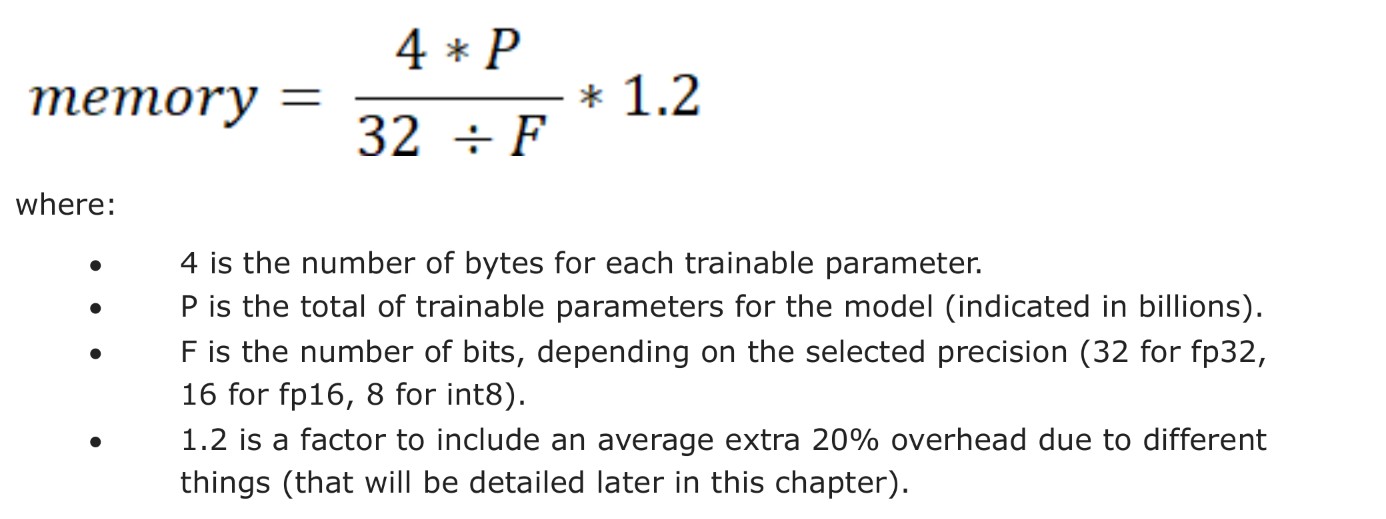

In [20]:
print("--- Data types of model parameters ---")

# Get the data type of the first parameter found
first_param_dtype = None
for name, param in model.named_parameters():
    if param.requires_grad: # Check for trainable parameters
        first_param_dtype = param.dtype
        print(f"Example parameter '{name}' has dtype: {param.dtype}")
        break

if first_param_dtype:
    print(f"\nMost (if not all) model parameters are likely of dtype: {first_param_dtype}")
else:
    print("No trainable parameters found in the model.")

# You can also directly check the model's overall dtype if it's set, though it's less direct for parameters
print(f"Model's overall dtype (if set): {model.dtype}")


--- Data types of model parameters ---
Example parameter 'transformer.wte.weight' has dtype: torch.float32

Most (if not all) model parameters are likely of dtype: torch.float32
Model's overall dtype (if set): torch.float32


The NVIDIA L4 GPU is a powerful accelerator often available in Google Colab environments, especially with Colab Pro or Pro+ subscriptions. Here are some typical specifications:

Architecture: NVIDIA Ada Lovelace
CUDA Cores: 7,680
Tensor Cores: 240 (4th Gen)
RT Cores: 60 (3rd Gen)
GPU Memory: 24 GB GDDR6
Memory Interface: 192-bit
Memory Bandwidth: 300 GB/s
FP32 Performance: Up to 30.3 TFLOPS
Tensor Float 32 (TF32) Performance: Up to 120 TFLOPS
INT8/INT4 Performance: Up to 241/483 TFLOPS
Power Consumption: 72W (single slot, passive cooling)

In [31]:
import time
import numpy as np
prompt = "The story so far: in the beginning, the universe was created."
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
for use_cache in (True, False):
  times = []
  for _ in range(6):
      start = time.time()
      generated_ids = model.generate(input_ids,
        do_sample=True,
        temperature=0.9,
        max_length=200,
        pad_token_id=50256,
        use_cache=use_cache)
      times.append(time.time() - start)
      print(f"Completed iteration with {len(times)} entries")
  print(f"{'Using' if use_cache else 'No'} KV cache: {round(np.mean(times), 3)} +- {round(np.std(times), 3)} seconds")

Completed iteration with 1 entries
Completed iteration with 2 entries
Completed iteration with 3 entries
Completed iteration with 4 entries
Completed iteration with 5 entries
Completed iteration with 6 entries
Using KV cache: 9.911 +- 0.015 seconds
Completed iteration with 1 entries
Completed iteration with 2 entries
Completed iteration with 3 entries
Completed iteration with 4 entries
Completed iteration with 5 entries
Completed iteration with 6 entries
No KV cache: 21.376 +- 0.112 seconds
